import pandas as pd

# Load kedua dataset
df_labeled = pd.read_csv("fakedataset.csv")
df_unlabeled = pd.read_csv("datasetindo.csv")

print("Data berlabel (English):", df_labeled.shape)
print("Data tidak berlabel (Indo translated):", df_unlabeled.shape)

# Lihat kolom yang tersedia
print("\nKolom fakedataset.csv:")
print(df_labeled.columns)
print("\nKolom datasetindo.csv:")
print(df_unlabeled.columns)

# Tampilkan 5 baris pertama
df_labeled.head()

In [2]:
import pandas as pd

# Load dataset
df_labeled = pd.read_csv("fakedataset.csv")
df_unlabeled = pd.read_csv("datasetindo.csv")

# Gunakan hanya kolom penting
df_labeled = df_labeled[['text_', 'label']]
df_unlabeled = df_unlabeled[['Customer Review_en']].rename(columns={'Customer Review_en':'text'})

# Cek nilai unik label
print("Label unik:", df_labeled['label'].unique())
df_labeled.head()


Label unik: ['CG' 'OR']


,text_,label
0,"Love this! Well made, sturdy, and very comfor...",CG
1,"love it, a great upgrade from the original. I...",CG
2,This pillow saved my back. I love the look and...,CG
3,"Missing information on how to use it, but it i...",CG
4,Very nice set. Good quality. We have had the s...,CG


In [3]:
df_labeled['label'] = df_labeled['label'].apply(lambda x: 1 if x == 'CG' else 0)


In [4]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+|#\w+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [stemmer.stem(w) for w in text.split() if w not in STOPWORDS]
    return " ".join(tokens)

df_labeled['clean_text'] = df_labeled['text_'].apply(clean_text)
df_unlabeled['clean_text'] = df_unlabeled['text'].apply(clean_text)


[nltk_data] Downloading package stopwords to C:\Users\willy
[nltk_data]     chen\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [5]:
from sklearn.model_selection import train_test_split

X = df_labeled['clean_text']
y = df_labeled['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 32345
Test size: 8087


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [8]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4044
           1       0.90      0.90      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087

ROC-AUC: 0.9651315739577974


In [9]:
X_unlabeled = df_unlabeled['clean_text']
X_unlabeled_tfidf = tfidf.transform(X_unlabeled)

proba = model.predict_proba(X_unlabeled_tfidf)
pseudo_pred = model.predict(X_unlabeled_tfidf)
confidence = proba.max(axis=1)

threshold = 0.75
selected_idx = confidence >= threshold

pseudo_X = X_unlabeled[selected_idx]
pseudo_y = pseudo_pred[selected_idx]

print("Jumlah pseudo data yang dipakai:", len(pseudo_X))


Jumlah pseudo data yang dipakai: 2309


In [10]:
from scipy.sparse import vstack
import numpy as np

X_train_aug = vstack([X_train_tfidf, tfidf.transform(pseudo_X)])
y_train_aug = np.concatenate([y_train, pseudo_y])


In [11]:
model_final = LogisticRegression(max_iter=1000, class_weight='balanced')
model_final.fit(X_train_aug, y_train_aug)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [12]:
y_pred_final = model_final.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, model_final.predict_proba(X_test_tfidf)[:,1]))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      4044
           1       0.89      0.90      0.90      4043

    accuracy                           0.90      8087
   macro avg       0.90      0.90      0.90      8087
weighted avg       0.90      0.90      0.90      8087

ROC-AUC: 0.964381232609977


In [13]:
import joblib

joblib.dump(model_final, "fake_review_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [14]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, roc_auc_score

# Latih model SVM
svm_model = LinearSVC(class_weight='balanced', max_iter=2000)
svm_model.fit(X_train_tfidf, y_train)

# Prediksi
y_pred_svm = svm_model.predict(X_test_tfidf)

# Evaluasi performa
print(classification_report(y_test, y_pred_svm))


              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4044
           1       0.91      0.91      0.91      4043

    accuracy                           0.91      8087
   macro avg       0.91      0.91      0.91      8087
weighted avg       0.91      0.91      0.91      8087



In [15]:
y_scores = svm_model.decision_function(X_test_tfidf)
roc_auc = roc_auc_score(y_test, y_scores)
print("ROC-AUC:", roc_auc)


ROC-AUC: 0.9708606637890942


In [16]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 0.5, 1, 5, 10],
    'max_iter': [1000, 2000, 3000]
}

grid_svm = GridSearchCV(
    LinearSVC(class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_svm.fit(X_train_tfidf, y_train)
print("✅ Best parameters:", grid_svm.best_params_)
print("✅ Best score:", grid_svm.best_score_)

# Ambil model terbaik
best_svm = grid_svm.best_estimator_

# Evaluasi di test set
y_pred_best = best_svm.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 15 candidates, totalling 75 fits
✅ Best parameters: {'C': 0.5, 'max_iter': 1000}
✅ Best score: 0.9022105425877263
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      4044
           1       0.91      0.91      0.91      4043

    accuracy                           0.91      8087
   macro avg       0.91      0.91      0.91      8087
weighted avg       0.91      0.91      0.91      8087



In [17]:
import pickle

with open("fake_review_svm_best.pkl", "wb") as f:
    pickle.dump(best_svm, f)
print("✅ Model SVM terbaik disimpan!")

✅ Model SVM terbaik disimpan!


In [18]:
!pip install shap

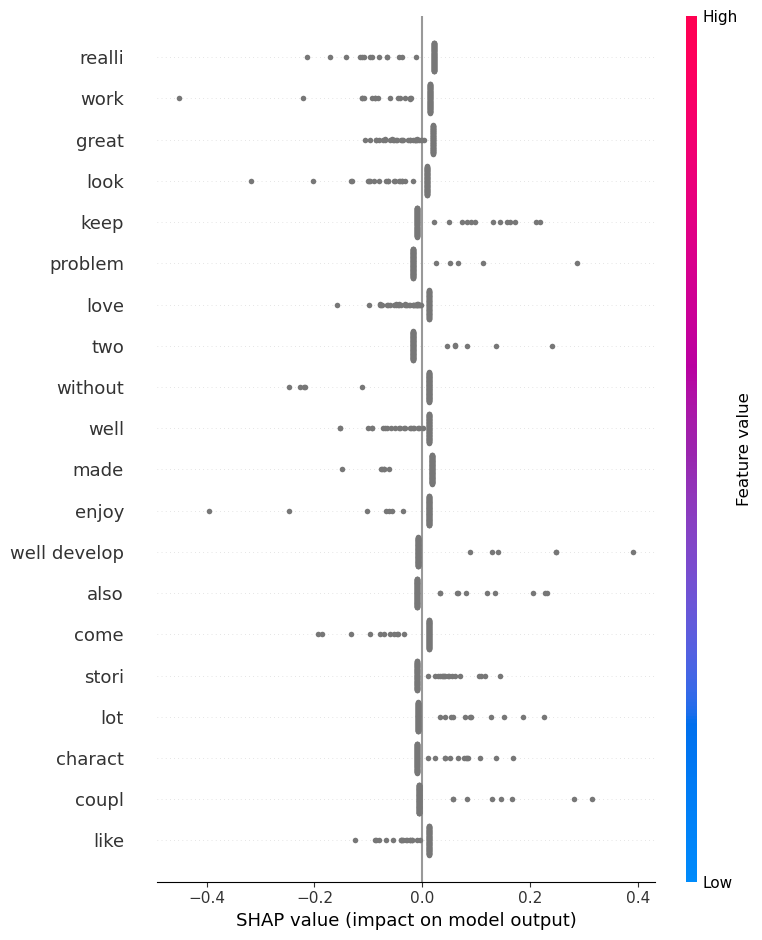

In [19]:
import shap

# Buat explainer untuk model linear (SVM)
explainer = shap.LinearExplainer(best_svm, X_train_tfidf, feature_names=tfidf.get_feature_names_out())

# Ambil subset data test untuk interpretasi
X_sample = X_test_tfidf[:100]

# Hitung SHAP values
shap_values = explainer.shap_values(X_sample)

# Visualisasi global (fitur paling berpengaruh)
shap.summary_plot(shap_values, X_sample, feature_names=tfidf.get_feature_names_out())


Review: realli like crome especi suction cup also love yellow


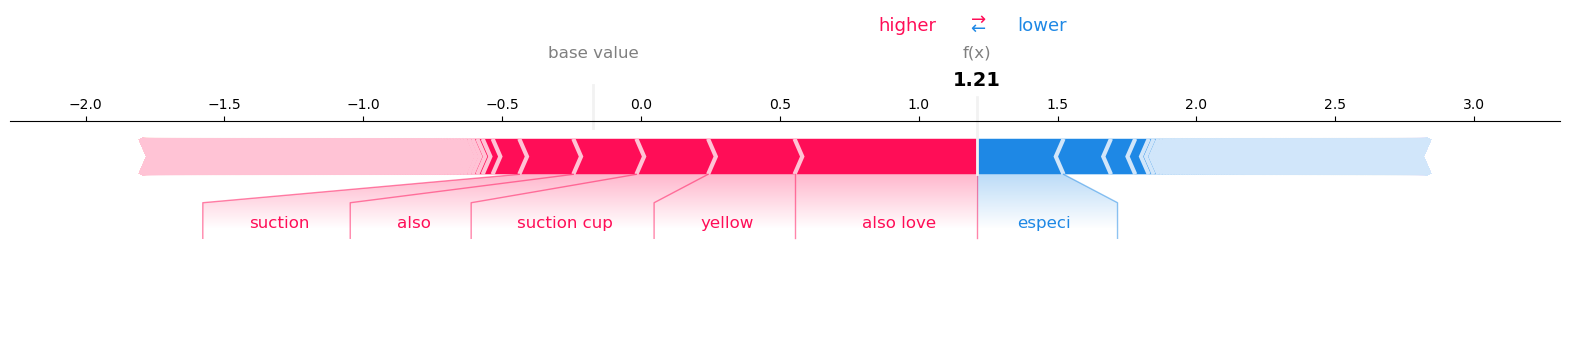

In [20]:
# Ambil 1 contoh review dari test
idx = 10
review_text = X_test.iloc[idx]
print("Review:", review_text)

# Dapatkan shap values untuk review ini
shap.force_plot(explainer.expected_value, shap_values[idx], feature_names=tfidf.get_feature_names_out(), matplotlib=True)


In [21]:
def predict_review_svm(review_text):
    # Bersihkan teks
    cleaned = clean_text(review_text)

    # Ubah ke vektor TF-IDF
    X_vec = tfidf.transform([cleaned])

    # Prediksi label
    pred = svm_model.predict(X_vec)[0]
    score = svm_model.decision_function(X_vec)[0]

    # Interpretasi label
    label = "FAKE REVIEW" if pred == 1 else "REAL REVIEW"

    print(f"Teks review: {review_text}")
    print(f"Hasil prediksi: {label}")
    print(f"Tingkat keyakinan (margin): {score:.4f}")


In [22]:
predict_review_svm("This product is awesome! Totally worth it, highly recommended!")
predict_review_svm("This item is a total scam, don't waste your money and dont buy this product.")

Teks review: This product is awesome! Totally worth it, highly recommended!
Hasil prediksi: REAL REVIEW
Tingkat keyakinan (margin): -1.0787
Teks review: This item is a total scam, don't waste your money and dont buy this product.
Hasil prediksi: REAL REVIEW
Tingkat keyakinan (margin): -0.4991


In [23]:
import numpy as np

def predict_review_svm(review_text):
    # Bersihkan teks
    cleaned = clean_text(review_text)

    # TF-IDF transform
    X_vec = tfidf.transform([cleaned])

    # Prediksi label & skor margin
    pred = svm_model.predict(X_vec)[0]
    margin = svm_model.decision_function(X_vec)[0]

    # Ubah margin ke probabilitas (pakai sigmoid)
    prob = 1 / (1 + np.exp(-margin))

    # Interpretasi label
    label = "FAKE REVIEW" if pred == 1 else "REAL REVIEW"

    # Pastikan persentase keyakinan ke label yang dipilih
    confidence = prob if pred == 1 else (1 - prob)

    print(f"Review: {review_text}")
    print(f"Prediksi: {label}")
    print(f"Tingkat keyakinan: {confidence*100:.2f}%")


In [24]:
predict_review_svm("This pillow saved my back. I love the look and feel of this pillow.")

Review: This pillow saved my back. I love the look and feel of this pillow.
Prediksi: FAKE REVIEW
Tingkat keyakinan: 70.95%


In [25]:
predict_review_svm("Amazing product! Exactly as described. Fast shipping, five stars! Highly recommend to everyone!")

Review: Amazing product! Exactly as described. Fast shipping, five stars! Highly recommend to everyone!
Prediksi: REAL REVIEW
Tingkat keyakinan: 77.86%


In [26]:
predict_review_svm("Winata handsome")

Review: Winata handsome
Prediksi: FAKE REVIEW
Tingkat keyakinan: 69.87%
